# Datos e ingeniería de variables — Colono IA

Recomendador de colocación inicial en Catan.

Este notebook muestra **de dónde salen los datos y cómo se construyen las variables**. Es el
primero de la serie:

1. `00_ingenieria_variables.ipynb` — este notebook: el tablero, las parejas, las 12 variables
   del modelo y la variable objetivo, calculadas paso a paso.
2. `01_eda.ipynb` — análisis exploratorio del dataset.
3. `02_modelo.ipynb` — regresión, evaluación y familias de estrategia.

**Relación con el documento final.** Sigue el **Capítulo 3 (Descripción de los datos)**, en
especial la **Sección 3.5 (Ingeniería de variables)**. Las fórmulas son las mismas del documento
y cada variable se calcula a mano y se compara con el código que usa la app
(`backend/app/domain/variables.py`), para comprobar que coinciden.

**Por qué es tan importante este paso.** El tablero en bruto es solo una lista de terrenos y
números. Lo que hace buena a una posición no está escrito en ningún lado: se deriva de las
reglas del juego. Cada variable traduce una regla (cuánto cuesta construir, cómo funciona el
comercio, dónde se puede colocar) en un número que el modelo puede usar.

## 1. Preparación

In [1]:
# En Google Colab, descomenta para clonar el repositorio:
# !git clone https://github.com/AnaaBohorquez/catanai.git
# %cd catanai

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Circle, RegularPolygon

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# La raíz del proyecto: la primera carpeta, subiendo desde la actual, que tiene data/processed.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir())
RUTA = RAIZ / "data" / "processed" / "parejas.csv"
OBJETIVO = "puntos"

# El código del juego vive en backend/app/domain y solo usa la biblioteca estándar de Python,
# así que se puede importar directamente, sin instalar el backend.
sys.path.insert(0, str(RAIZ / "backend"))
from app.domain.tablero import (
    COSTOS, FICHAS, PIPS, RECURSOS, TERRENOS, generar_tablero, hexagonos_del_vertice,
    pips_del_vertice, puerto_del_vertice, todas_las_aristas, todos_los_vertices,
    vertices_adyacentes, verificar_tablero,
)
from app.domain.simulador import parejas_candidatas, simular_pareja
from app.domain.variables import variables_de_pareja, variables_de_parejas

VARIABLES_MODELO = [
    "produccion_efectiva", "par_camino", "par_ciudad", "trio_desarrollo",
    "cuarteto_poblado", "desequilibrio", "puerto_alineado", "puerto_generico",
    "vertices_expansion_2", "jugadores", "num_hexagonos", "solapamiento",
]

In [2]:
# Estilo de las gráficas: el mismo del documento y de los otros notebooks.
AZUL, TERRACOTA, VERDE, DORADO = "#2F6AA3", "#C8643C", "#1F978A", "#A8861F"
TINTA, TENUE, REJILLA, GRIS = "#2b2b2b", "#6b6b6b", "#e6e6e6", "#9e9e9e"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.edgecolor": "#bdbdbd", "axes.labelcolor": TINTA,
    "xtick.color": TENUE, "ytick.color": TENUE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 9.5, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "figure.dpi": 110,
})

## 2. Representación del tablero

*Documento, Sección 3.1.*

Cada hexágono se identifica con una **coordenada axial** $(q, r)$: $r$ es la fila y $q$ la
posición dentro de ella. La decisión de diseño más importante es cómo representar los vértices:
**cada vértice es el conjunto de los tres hexágonos que toca**. De ahí salen gratis los pips de
un vértice (la suma de los de sus hexágonos) y la regla de distancia (dos vértices son vecinos si
comparten exactamente dos hexágonos).

Se usa como ejemplo el tablero con semilla 125, el mismo del Capítulo 6 del documento. Es un
tablero de prueba: el modelo nunca lo vio al entrenar.

In [3]:
SEMILLA = 125
JUGADORES = 3 if SEMILLA % 2 else 4   # el dataset alterna 3 y 4 jugadores por tablero
tablero = generar_tablero(semilla=SEMILLA)
verificar_tablero(tablero)            # falla si alguna cantidad no cuadra con el juego base

vertices = todos_los_vertices()
print(f"Hexágonos:        {len(tablero['hexagonos'])}")
print(f"Vértices:         {len(vertices)}")
print(f"Aristas:          {len(todas_las_aristas())}")
print(f"Fichas numéricas: {len(tablero['numeros'])}")
print(f"Pips en total:    {sum(tablero['pips'].values())}")
print(f"Puertos:          {len(tablero['puertos'])}")

ejemplo = sorted(vertices, key=lambda v: -pips_del_vertice(v, tablero))[0]
print(f"\nUn vértice es un conjunto de hexágonos: {sorted(ejemplo)}")
print(f"Sus pips: {pips_del_vertice(ejemplo, tablero)}")

Hexágonos:        19
Vértices:         54
Aristas:          72
Fichas numéricas: 18
Pips en total:    58
Puertos:          9

Un vértice es un conjunto de hexágonos: [(-1, -1), (0, -2), (0, -1)]
Sus pips: 12


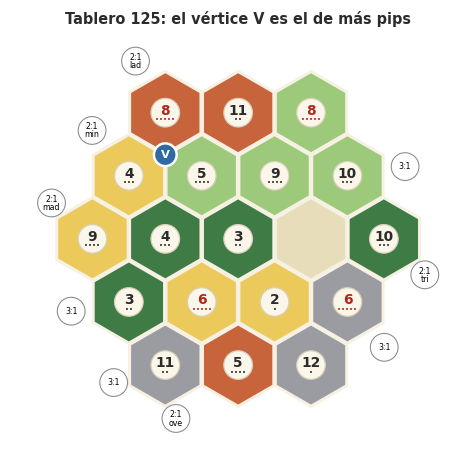

In [4]:
COLOR_TERRENO = {"bosque": "#3E7B45", "pastos": "#9CC97A", "campos": "#EBC95A",
                 "colinas": "#C8643C", "montanas": "#9A9CA1", "desierto": "#E8DDBB"}

def centro(h):
    """Coordenada axial -> punto en el plano (hexágonos con punta hacia arriba)."""
    q, r = h
    return np.sqrt(3) * (q + r / 2), -1.5 * r

def posicion(v):
    """Un vértice está en el promedio de los centros de sus tres hexágonos."""
    return np.mean([centro(h) for h in v], axis=0)

def dibujar_tablero(ax, tablero):
    for h in tablero["hexagonos"]:
        x, y = centro(h)
        ax.add_patch(RegularPolygon((x, y), 6, radius=0.98, orientation=0,
                                    facecolor=COLOR_TERRENO[tablero["terrenos"][h]],
                                    edgecolor="#f7f1e3", lw=2))
        n = tablero["numeros"].get(h)
        if n:
            ax.add_patch(Circle((x, y), 0.34, facecolor="#fbf6ea", edgecolor="#d9cfb8", lw=0.8))
            color = "#b3261e" if n in (6, 8) else TINTA
            ax.text(x, y + 0.06, str(n), ha="center", va="center", fontsize=9, fontweight="bold", color=color)
            ax.text(x, y - 0.17, "•" * PIPS[n], ha="center", va="center", fontsize=4.5, color=color)
    for arista, tipo in tablero["puertos"].items():
        a, b = list(arista)
        p = (posicion(a) + posicion(b)) / 2
        q = p + p / np.linalg.norm(p) * 0.55
        ax.add_patch(Circle(q, 0.33, facecolor="white", edgecolor="#8a8a8a", lw=0.7))
        ax.text(q[0], q[1], "3:1" if tipo == "3:1" else "2:1\n" + tipo[:3],
                ha="center", va="center", fontsize=5.2, linespacing=0.9)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-5.4, 5.4)
    ax.set_ylim(-4.9, 4.9)

def marcar(ax, v, color, etiqueta):
    x, y = posicion(v)
    ax.add_patch(Circle((x, y), 0.27, facecolor=color, edgecolor="white", lw=1.6, zorder=6))
    ax.text(x, y, etiqueta, ha="center", va="center", fontsize=7.5, fontweight="bold", color="white", zorder=7)

fig, ax = plt.subplots(figsize=(4.4, 4.2))
dibujar_tablero(ax, tablero)
marcar(ax, ejemplo, AZUL, "V")
ax.set_title(f"Tablero {SEMILLA}: el vértice V es el de más pips")
plt.tight_layout()
plt.show()

## 3. De vértices sueltos a parejas

En Catan no se coloca un poblado, se colocan **dos**, y lo que aporta uno depende del otro. Un
vértice toca como máximo tres hexágonos, así que rara vez produce a la vez los dos recursos de un
camino. Una pareja toca hasta seis. Se mide en los primeros 50 tableros del dataset:

In [5]:
def produce(recursos_del_vertice, *recursos):
    return all(recursos_del_vertice.get(r, 0) > 0 for r in recursos)

def recursos_de(v, t):
    salida = {}
    for h in hexagonos_del_vertice(v, t):
        r = t["recursos"][h]
        if r is not None:
            salida[r] = salida.get(r, 0) + t["pips"][h]
    return salida

vertice_ml, pareja_ml = [], []
for s in range(50):
    t = generar_tablero(semilla=s)
    vertice_ml += [produce(recursos_de(v, t), "madera", "ladrillo") for v in todos_los_vertices()]
    for v1, v2 in parejas_candidatas(t):
        r1, r2 = recursos_de(v1, t), recursos_de(v2, t)
        juntos = {r: r1.get(r, 0) + r2.get(r, 0) for r in RECURSOS}
        pareja_ml.append(produce(juntos, "madera", "ladrillo"))

print(f"Vértices sueltos con madera Y ladrillo:   {np.mean(vertice_ml):.0%}")
print(f"Parejas candidatas con madera Y ladrillo: {np.mean(pareja_ml):.0%}")

Vértices sueltos con madera Y ladrillo:   10%
Parejas candidatas con madera Y ladrillo: 43%


Esa diferencia es la razón de modelar **parejas**: con vértices sueltos, la combinación que
permite construir caminos casi nunca aparece.

### Parejas candidatas

*Documento, Sección 3.4.* Un tablero admite 1,431 parejas, casi todas malas. Se preseleccionan
los 15 vértices con más pips y, además, los 6 mejores vértices con puerto (los de la costa tocan
menos hexágonos y nunca entrarían por pips). Con ellos se forman las parejas que respetan la
regla de distancia.

In [6]:
parejas = parejas_candidatas(tablero)
con_puerto = sum(1 for v1, v2 in parejas if puerto_del_vertice(v1, tablero) or puerto_del_vertice(v2, tablero))
print(f"Parejas posibles en un tablero: {len(vertices) * (len(vertices) - 1) // 2:,}")
print(f"Parejas candidatas en el tablero {SEMILLA}: {len(parejas)}")
print(f"De ellas, con algún puerto: {con_puerto}")

Parejas posibles en un tablero: 1,431
Parejas candidatas en el tablero 125: 190
De ellas, con algún puerto: 101


## 4. Las variables, paso a paso

*Documento, Sección 3.5.* Se toma la mejor pareja de este tablero (la opción 1 del ejemplo del
Capítulo 6) y se calcula cada variable **a mano**, con la fórmula del documento. Al final se
compara con lo que devuelve `variables_de_pareja()`, la función que usan el dataset y la app.

### 4.1 La materia prima: pips por recurso

Para una pareja $v_1, v_2$ y un recurso $r$, $p_r$ es la suma de los pips de los hexágonos de ese
recurso que tocan los dos poblados. Si ambos tocan el mismo hexágono, cuenta dos veces: cada
poblado cobra su propia carta.

In [7]:
# La opción 1 del ejemplo del documento: la pareja de este tablero con más puntos simulados.
dataset = pd.read_csv(RUTA)
del_tablero = dataset[dataset["tablero_id"] == SEMILLA].set_index("pareja_id")
filas = variables_de_parejas(tablero, parejas, JUGADORES)
mejor = max(range(len(parejas)), key=lambda i: del_tablero.loc[filas[i]["pareja_id"], OBJETIVO])
v1, v2 = parejas[mejor]

H1, H2 = hexagonos_del_vertice(v1, tablero), hexagonos_del_vertice(v2, tablero)
filas_hex = []
for poblado, hexs in [("poblado 1", H1), ("poblado 2", H2)]:
    for h in hexs:
        filas_hex.append({"poblado": poblado, "hexágono": h, "terreno": tablero["terrenos"][h],
                          "recurso": tablero["recursos"][h], "número": tablero["numeros"].get(h),
                          "pips": tablero["pips"][h]})
pd.DataFrame(filas_hex)

,poblado,hexágono,terreno,recurso,número,pips
0,poblado 1,"(-2, 2)",montanas,mineral,11,2
1,poblado 1,"(-1, 1)",campos,trigo,6,5
2,poblado 1,"(-1, 2)",colinas,ladrillo,5,4
3,poblado 2,"(-1, 0)",bosque,madera,4,3
4,poblado 2,"(0, -1)",pastos,oveja,5,4
5,poblado 2,"(0, 0)",bosque,madera,3,2


In [8]:
p = {r: 0 for r in RECURSOS}
for h in H1 + H2:                       # con repetición, a propósito
    if tablero["recursos"][h] is not None:
        p[tablero["recursos"][h]] += tablero["pips"][h]
P = sum(p.values())
print("p_r =", p)
print("P   =", P)
print(f"\nCartas esperadas por ronda con {JUGADORES} jugadores (p_r · J / 36):")
print({r: round(p[r] * JUGADORES / 36, 2) for r in RECURSOS})

p_r = {'madera': 5, 'ladrillo': 4, 'trigo': 5, 'oveja': 4, 'mineral': 2}
P   = 20

Cartas esperadas por ronda con 3 jugadores (p_r · J / 36):
{'madera': 0.42, 'ladrillo': 0.33, 'trigo': 0.42, 'oveja': 0.33, 'mineral': 0.17}


### 4.2 Producción ajustada por el comercio

**1. Producción efectiva.** Un recurso sobrante solo sirve si se cambia, y el cambio tiene un
precio: 4:1 en el banco, 3:1 con un puerto genérico, 2:1 con el puerto de ese recurso. Se toma
como referencia el reparto parejo $\bar p = P/5$; lo que está por debajo cuenta completo y el
excedente se divide entre su tasa de cambio:

$$\text{produccion\_efectiva} = \sum_r \Big[\min(p_r, \bar p) + \frac{\max(0,\, p_r - \bar p)}{t_r}\Big]$$

**2. Desequilibrio.** Qué tan concentrada está la producción: $\max_r p_r / P$. Vale 0.2 si
todo está repartido y 1 si viene de un solo recurso.

In [9]:
puertos = {x for x in (puerto_del_vertice(v1, tablero), puerto_del_vertice(v2, tablero)) if x}

def tasa(recurso):
    if recurso in puertos:
        return 2
    return 3 if "3:1" in puertos else 4

referencia = P / 5
a_mano = {}
a_mano["produccion_efectiva"] = sum(
    min(p[r], referencia) + max(0, p[r] - referencia) / tasa(r) for r in RECURSOS
)
a_mano["desequilibrio"] = max(p.values()) / P
print(f"Puertos de la pareja: {puertos or 'ninguno'}")
print(f"Reparto parejo: {P}/5 = {referencia:.1f}")
print(f"produccion_efectiva = {a_mano['produccion_efectiva']:.2f}   (de {P} pips)")
print(f"desequilibrio       = {a_mano['desequilibrio']:.2f}")

Puertos de la pareja: ninguno
Reparto parejo: 20/5 = 4.0
produccion_efectiva = 18.50   (de 20 pips)
desequilibrio       = 0.25


### 4.3 Capacidad de completar construcciones

Estas cuatro variables traducen la tabla de costos. Todas usan el **mínimo**, no la suma: una
construcción exige todos sus recursos y el más escaso marca el ritmo.

- **3. `par_camino`** $= \min(p_{madera}, p_{ladrillo})$ — camino.
- **4. `par_ciudad`** $= \min(p_{trigo}/2,\ p_{mineral}/3)$ — ciudad: dos trigos y tres minerales.
- **5. `trio_desarrollo`** $= \min(p_{trigo}, p_{oveja}, p_{mineral})$ — carta de desarrollo.
- **6. `cuarteto_poblado`** $= \min(p_{madera}, p_{ladrillo}, p_{trigo}, p_{oveja})$ — poblado.
  Solo existe a nivel de pareja: un vértice nunca toca los cuatro recursos.

In [10]:
print("Costos del juego:", COSTOS, "\n")
a_mano["par_camino"] = min(p["madera"], p["ladrillo"])
a_mano["par_ciudad"] = min(p["trigo"] / 2, p["mineral"] / 3)
a_mano["trio_desarrollo"] = min(p["trigo"], p["oveja"], p["mineral"])
a_mano["cuarteto_poblado"] = min(p["madera"], p["ladrillo"], p["trigo"], p["oveja"])
for k in ["par_camino", "par_ciudad", "trio_desarrollo", "cuarteto_poblado"]:
    print(f"{k:18s} = {a_mano[k]:.2f}")

Costos del juego: {'camino': {'madera': 1, 'ladrillo': 1}, 'poblado': {'madera': 1, 'ladrillo': 1, 'trigo': 1, 'oveja': 1}, 'ciudad': {'trigo': 2, 'mineral': 3}, 'carta_desarrollo': {'trigo': 1, 'oveja': 1, 'mineral': 1}} 

par_camino         = 4.00
par_ciudad         = 0.67
trio_desarrollo    = 2.00
cuarteto_poblado   = 4.00


### 4.4 Puertos

- **7. `puerto_alineado`** = 1 si algún poblado está en el puerto 2:1 del recurso que la pareja
  **más produce**. Un puerto específico solo vale de verdad si coincide con el sobrante.
- **8. `puerto_generico`** = 1 si algún poblado está en un puerto 3:1.

In [11]:
dominante = max(RECURSOS, key=lambda r: p[r])
a_mano["puerto_alineado"] = float(dominante in puertos and p[dominante] > 0)
a_mano["puerto_generico"] = float("3:1" in puertos)
print(f"Recurso dominante: {dominante}")
print(f"puerto_alineado = {a_mano['puerto_alineado']:.0f} | puerto_generico = {a_mano['puerto_generico']:.0f}")

Recurso dominante: madera
puerto_alineado = 0 | puerto_generico = 0


### 4.5 Posición en el tablero y contexto

- **9. `vertices_expansion_2`**: vértices libres exactamente a dos aristas de algún poblado. Los
  vecinos inmediatos nunca son legales (regla de distancia); a dos aristas es justo donde se
  funda el siguiente poblado con un par de caminos.
- **10. `num_hexagonos`**: hexágonos de tierra que tocan los dos poblados (2 a 6). Distingue el
  centro de la costa y le permite al modelo separar el efecto del puerto del de estar en la costa.
- **11. `solapamiento`**: hexágonos que comparten los dos poblados.
- **12. `jugadores`**: 3 o 4. Más jugadores, más tiradas por ronda.

In [12]:
# Distancias en aristas desde cada poblado (recorrido en anchura sobre el grafo de vértices).
adyacentes = {v: vertices_adyacentes(v, vertices) for v in vertices}

def distancias(origen):
    dist, cola = {origen: 0}, [origen]
    while cola:
        actual = cola.pop(0)
        for vecino in adyacentes[actual]:
            if vecino not in dist:
                dist[vecino] = dist[actual] + 1
                cola.append(vecino)
    return dist

bloqueados = {v1, v2} | set(adyacentes[v1]) | set(adyacentes[v2])
libres_a_2 = {v for origen in (v1, v2) for v, d in distancias(origen).items()
              if d == 2 and v not in bloqueados}

a_mano["vertices_expansion_2"] = len(libres_a_2)
a_mano["num_hexagonos"] = len(H1) + len(H2)
a_mano["solapamiento"] = len(set(H1) & set(H2))
a_mano["jugadores"] = JUGADORES
for k in ["vertices_expansion_2", "num_hexagonos", "solapamiento", "jugadores"]:
    print(f"{k:22s} = {a_mano[k]}")

vertices_expansion_2   = 10
num_hexagonos          = 6
solapamiento           = 0
jugadores              = 3


### 4.6 Comprobación: a mano contra el código de la app

In [13]:
del_codigo = variables_de_pareja(v1, v2, tablero, JUGADORES)
comparacion = pd.DataFrame({
    "a mano": {k: a_mano[k] for k in VARIABLES_MODELO},
    "variables.py": {k: del_codigo[k] for k in VARIABLES_MODELO},
})
comparacion["coinciden"] = np.isclose(comparacion["a mano"], comparacion["variables.py"])
assert comparacion["coinciden"].all(), "Alguna variable no coincide"
comparacion.round(3)

,a mano,variables.py,coinciden
produccion_efectiva,18.500,18.500,True
par_camino,4.000,4.000,True
par_ciudad,0.667,0.667,True
trio_desarrollo,2.000,2.000,True
cuarteto_poblado,4.000,4.000,True
desequilibrio,0.250,0.250,True
puerto_alineado,0.000,0.000,True
puerto_generico,0.000,0.000,True
vertices_expansion_2,10.000,10.000,True
jugadores,3.000,3.000,True


Las 12 variables calculadas con las fórmulas del documento coinciden con las del código. El
dataset, el modelo y la app usan exactamente estas definiciones.

La gráfica marca la pareja en el tablero:

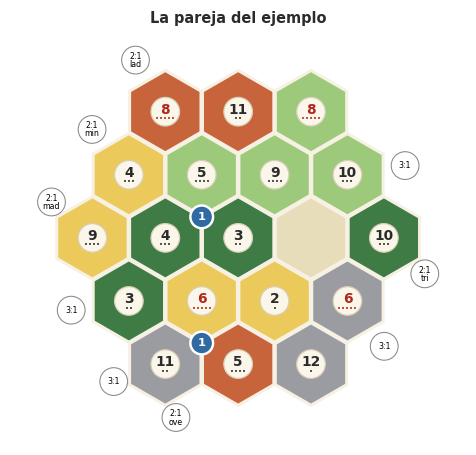

In [14]:
fig, ax = plt.subplots(figsize=(4.4, 4.2))
dibujar_tablero(ax, tablero)
marcar(ax, v1, AZUL, "1")
marcar(ax, v2, AZUL, "1")
ax.set_title("La pareja del ejemplo")
plt.tight_layout()
plt.show()

## 5. Las 12 variables en todo el dataset

*Documento, Tabla «Las 12 variables del modelo».* Estadísticas descriptivas y correlación de
Pearson con los puntos simulados.

In [15]:
resumen = dataset[VARIABLES_MODELO].describe().T[["mean", "std", "min", "max"]]
resumen.columns = ["media", "desv.", "mín.", "máx."]
resumen["corr. con puntos"] = dataset[VARIABLES_MODELO].corrwith(dataset[OBJETIVO])
resumen.round(2)

,media,desv.,mín.,máx.,corr. con puntos
produccion_efectiva,13.58,3.01,3.20,23.90,0.59
par_camino,1.49,1.94,0.00,10.00,0.36
par_ciudad,0.62,0.77,0.00,4.33,0.21
trio_desarrollo,0.85,1.44,0.00,7.00,0.41
cuarteto_poblado,0.44,1.00,0.00,5.00,0.52
desequilibrio,0.47,0.13,0.21,1.00,-0.41
puerto_alineado,0.07,0.26,0.00,1.00,-0.03
puerto_generico,0.29,0.45,0.00,1.00,-0.14
vertices_expansion_2,9.19,1.82,4.00,12.00,0.26
jugadores,3.50,0.50,3.00,4.00,0.33


## 6. El criterio de variabilidad

La app ordena las parejas **de un mismo tablero**. Una cantidad que valga igual para todas ellas
no puede explicar por qué una es mejor que otra. Por eso cada variable se revisa dentro de cada
tablero: si su desviación es cero en todos, no distingue nada. Así se eliminaron, durante el
desarrollo, variables como el total de pips del tablero o los pips relativos.

In [16]:
desv_dentro = dataset.groupby("tablero_id")[VARIABLES_MODELO].std().mean().round(3)
desv_dentro.to_frame("desviación promedio dentro de cada tablero")

,desviación promedio dentro de cada tablero
produccion_efectiva,2.918
par_camino,1.802
par_ciudad,0.722
trio_desarrollo,1.356
cuarteto_poblado,0.962
desequilibrio,0.126
puerto_alineado,0.240
puerto_generico,0.438
vertices_expansion_2,1.810
jugadores,0.000


Todas varían dentro de cada tablero **excepto `jugadores`**, que es igual para toda la mesa. Se
conserva por otra razón: con más jugadores hay más tiradas por ronda y más puntos, así que ajusta
el **nivel** de la estimación para que los puntos que ve el usuario correspondan a su mesa. No
cambia el orden de las recomendaciones.

## 7. De 40 variables calculadas a 12 en el modelo

Se calcularon 40 variables en ocho familias. Las que quedaron fuera no se descartaron por inútiles,
sino por **redundantes**: miden casi lo mismo que otra que sí entra, y mantenerlas reparte el
efecto entre coeficientes que dejan de ser interpretables.

In [17]:
pares = [("pips_madera", "control_madera"),
         ("pips_totales", "produccion_efectiva"),
         ("num_hexagonos", "hexagonos_distintos")]
for a, b in pares:
    print(f"corr({a}, {b}) = {dataset[a].corr(dataset[b]):.2f}")

print(f"\nCorrelación con los puntos — pips_totales: {dataset['pips_totales'].corr(dataset[OBJETIVO]):.2f} "
      f"| produccion_efectiva: {dataset['produccion_efectiva'].corr(dataset[OBJETIVO]):.2f}")

corr(pips_madera, control_madera) = 0.96
corr(pips_totales, produccion_efectiva) = 0.85
corr(num_hexagonos, hexagonos_distintos) = 0.89

Correlación con los puntos — pips_totales: 0.41 | produccion_efectiva: 0.59


La producción efectiva mide lo mismo que los pips totales, pero de forma más fina: descuenta lo
que no se puede gastar. Por eso entra al modelo en su lugar y se relaciona más con los puntos.
El análisis completo de colinealidad (11 pares por encima de 0.85 y el VIF de las 12 variables)
está en `01_eda.ipynb`, Sección 5.1.

## 8. La variable objetivo: puntos simulados

*Documento, Sección 3.3.* El simulador sigue al jugador durante 20 rondas. En cada ronda se tiran
los dados una vez por jugador de la mesa (se cobra en todas las tiradas), se construye lo que se
puede pagar en orden de prioridad (ciudad, poblado, camino, carta) y, si no alcanza, se cambia el
sobrante. La variable `puntos` es el promedio de 40 mini-partidas.

El dataset es reproducible: con la misma semilla, la simulación da exactamente el mismo valor.

In [18]:
simulado = simular_pareja(tablero, v1, v2, partidas=40, jugadores=JUGADORES, semilla=SEMILLA)
en_dataset = del_tablero.loc[filas[mejor]["pareja_id"], OBJETIVO]
print(f"Puntos simulados ahora:  {simulado:.3f}")
print(f"Puntos en el dataset:    {en_dataset:.3f}")
assert np.isclose(simulado, en_dataset)

Puntos simulados ahora:  7.775
Puntos en el dataset:    7.775


### ¿Cuánto ruido tiene la variable objetivo?

Cada valor de `puntos` es un promedio de 40 partidas, y los dados son aleatorios. Para medir qué
tan estable es ese promedio se repite **todo el procedimiento** 12 veces con dados distintos:
12 simulaciones × 40 partidas = 480 mini-partidas por pareja, que dan 12 promedios.

Primero con la pareja del ejemplo:

In [19]:
repeticiones = [simular_pareja(tablero, v1, v2, partidas=40, jugadores=JUGADORES, semilla=s)
                for s in range(1000, 1012)]
print("12 promedios:", np.round(repeticiones, 2))
print(f"Desviación entre repeticiones: {np.std(repeticiones, ddof=1):.2f} puntos")

12 promedios: [6.75 7.38 7.85 7.52 7.08 7.42 7.52 6.05 7.05 7.   6.85 7.22]
Desviación entre repeticiones: 0.47 puntos


El ruido cambia de una pareja a otra, así que una sola no basta. Se repite la medición con
**40 parejas elegidas al azar** de 40 tableros distintos (tarda unos segundos):

In [20]:
rng = np.random.default_rng(0)
mediciones = []
for s in rng.choice(200, 40, replace=False):
    t = generar_tablero(semilla=int(s))
    jugadores = 3 if s % 2 else 4
    candidatas = parejas_candidatas(t)
    a, b = candidatas[int(rng.integers(len(candidatas)))]
    r = [simular_pareja(t, a, b, partidas=40, jugadores=jugadores, semilla=k) for k in range(1000, 1012)]
    mediciones.append({"tablero": int(s), "puntos": np.mean(r), "ruido": np.std(r, ddof=1)})
mediciones = pd.DataFrame(mediciones)

ruido_tipico = np.sqrt((mediciones["ruido"] ** 2).mean())
print(f"Ruido típico (raíz de la varianza promedio): {ruido_tipico:.2f} puntos")
print(f"Desviación de los puntos en todo el dataset: {dataset[OBJETIVO].std():.2f} puntos")
print(f"El ruido equivale al {ruido_tipico ** 2 / dataset[OBJETIVO].var():.1%} de la varianza")
print(f"\nCorrelación entre los puntos de la pareja y su ruido: {mediciones['puntos'].corr(mediciones['ruido']):.2f}")

Ruido típico (raíz de la varianza promedio): 0.27 puntos
Desviación de los puntos en todo el dataset: 1.57 puntos
El ruido equivale al 3.0% de la varianza

Correlación entre los puntos de la pareja y su ruido: 0.75


El ruido de la simulación es pequeño frente a las diferencias entre parejas: alrededor del 3 % de
la varianza. Las parejas buenas son algo más ruidosas (por eso la del ejemplo varía más), porque
construyen más y cada dado les cambia más el resultado. En `02_modelo.ipynb` se usa esta medición
para mostrar que lo que el modelo no explica no es azar de los dados.

## 9. Conclusiones

- **El tablero se representa sin geometría**: cada vértice es el conjunto de sus hexágonos, y de
  ahí salen los pips, la regla de distancia y la costa.
- **La unidad de análisis es la pareja**, porque con vértices sueltos la combinación madera y
  ladrillo casi nunca aparece.
- **Las 12 variables traducen reglas del juego**: producción útil tras el comercio, capacidad de
  completar cada construcción, puertos que coinciden con el sobrante y espacio para crecer.
- **Las fórmulas del documento coinciden con el código de la app**, comprobado variable por
  variable.
- **Todas las variables distinguen parejas dentro de un tablero**, salvo `jugadores`, que ajusta el
  nivel de la estimación.
- **La variable objetivo es reproducible y su ruido es pequeño.**

Siguiente paso: `01_eda.ipynb`, con el análisis exploratorio del dataset completo.